
Filtrando dados para a cidade: Karachi
Dados divididos em Treino (80%) e Teste (20%).
Dados de treino: 17636 amostras
Dados de teste: 4409 amostras

--- PARÂMETROS DE SUCESSO (VALIDAÇÃO) ---
R² (R-squared): 0.7365
MAE (Erro Médio Absoluto): 323.97 (em $/m²)
------------------------------------------

Gerando gráfico de Previsão vs. Real...


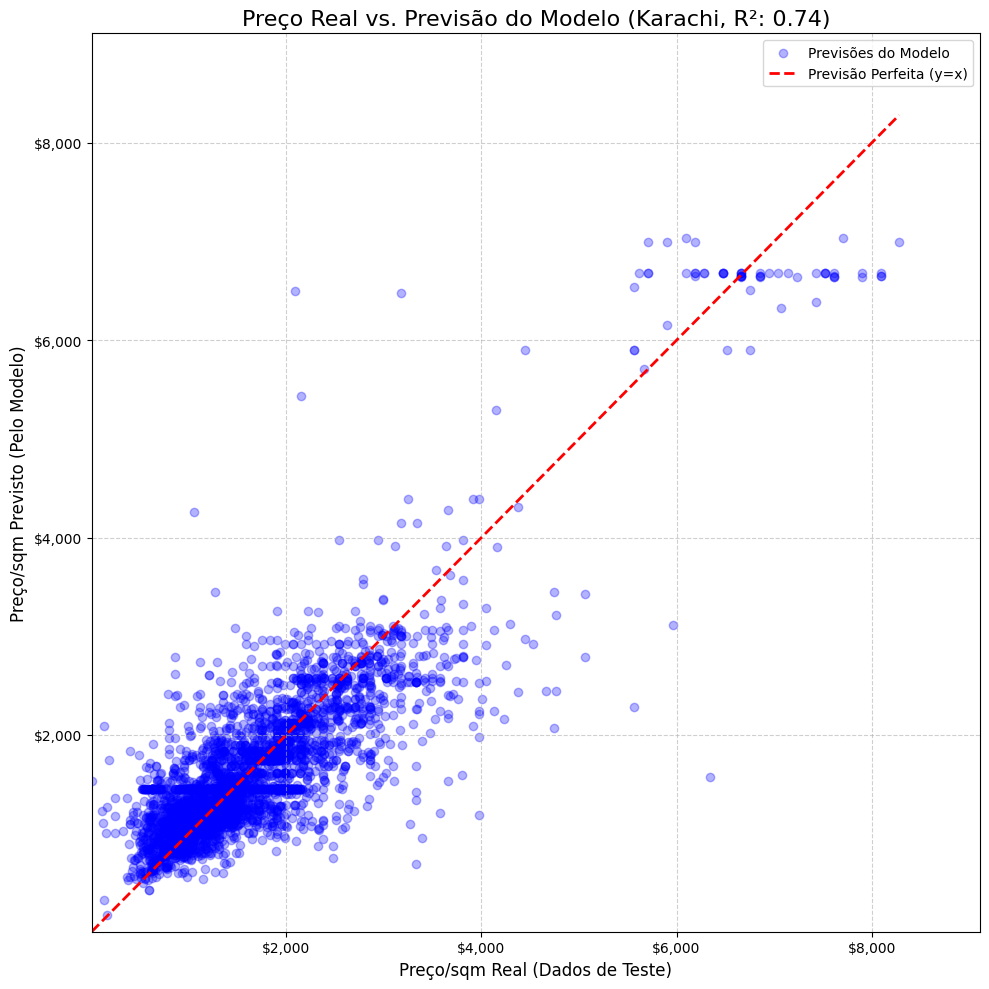


 SIMULADOR (AUTOMÁTICO) 

Propriedade Base (Média de Karachi):
  Flat em Bahria Town Karachi, 142.0m², 3q, 3b
Preço/m² Previsto (Base): 1,196.85

Simulação 1: Mudar para o bairro mais caro (Hoshang Road)
Preço/m² Previsto: 1,565.17  (Impacto: +368.32)

Simulação 2: Mudar tipo para 'Penthouse'
Preço/m² Previsto: 1,135.97  (Impacto: -60.88)

Simulação 3: Adicionar 2 banheiros (total: 5)
Preço/m² Previsto: 1,774.01  (Impacto: +577.16)
------------------------------------------



In [ ]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
import matplotlib.ticker as mticker


import ipywidgets as widgets
from ipywidgets import interact, HBox, VBox, Layout
from IPython.display import display, clear_output

# Define o nome do arquivo
file_name = "dataset_tratado.csv"

try:
    df = pd.read_csv(file_name)

    # print("Aplicando o tratamento de dados.")
    clean_df = df.copy()

    clean_df['price'] = pd.to_numeric(clean_df['price'], errors='coerce')
    clean_df['baths'] = pd.to_numeric(clean_df['baths'], errors='coerce')
    clean_df['bedrooms'] = pd.to_numeric(clean_df['bedrooms'], errors='coerce')

    ml_df = clean_df[clean_df['purpose'] == 'For Sale'].copy()
    ml_df['price_per_sqm'] = ml_df['price'] / ml_df['area']
    
    ml_df = ml_df.dropna(subset=['price', 'property_type', 'city', 'location', 'baths', 'bedrooms', 'area', 'price_per_sqm'])
    ml_df = ml_df[~np.isinf(ml_df['price_per_sqm'])]

    city_to_analyze = "Karachi"
    print(f"\nFiltrando dados para a cidade: {city_to_analyze}")
    
    df_city = ml_df[ml_df['city'] == city_to_analyze].copy()
    
    if df_city.empty:
        print(f"Nenhum dado restou para a cidade {city_to_analyze}. !!!")
    else:

        y = df_city['price_per_sqm']
        
        X = df_city.drop(['price', 'price_per_sqm', 'city', 'purpose', 'price_per_m2'], axis=1)


        print("Dados divididos em Treino (80%) e Teste (20%).")
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )
        print(f"Dados de treino: {len(X_train)} amostras")
        print(f"Dados de teste: {len(X_test)} amostras")

        
        numeric_features = ['baths', 'bedrooms', 'area']
        categorical_features = ['property_type', 'location'] 

        preprocessor = ColumnTransformer(
            transformers=[
                ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
            ],
            remainder='passthrough'
        )

        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
        ])

        pipeline.fit(X_train, y_train)

        y_pred = pipeline.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)

        print("\n--- PARÂMETROS DE SUCESSO (VALIDAÇÃO) ---")
        print(f"R² (R-squared): {r2:.4f}")
        print(f"MAE (Erro Médio Absoluto): {mae:,.2f} (em $/m²)")
        print("------------------------------------------")
        
        # (Gráfico de Dispersão)
        print("\nGerando gráfico de Previsão vs. Real...")
        
        plt.figure(figsize=(10, 10))
        plt.scatter(y_test, y_pred, alpha=0.3, color='blue', label='Previsões do Modelo')
        
        min_val = min(y_test.min(), y_pred.min())
        max_val = max(y_test.max(), y_pred.max())
        
        plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Previsão Perfeita (y=x)')
        
        plt.title(f'Preço Real vs. Previsão do Modelo (Karachi, R²: {r2:.2f})', fontsize=16)
        plt.xlabel('Preço/sqm Real (Dados de Teste)', fontsize=12)
        plt.ylabel('Preço/sqm Previsto (Pelo Modelo)', fontsize=12)
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)
        
        formatter = mticker.FuncFormatter(lambda x, p: f'${x:,.0f}')
        plt.gca().xaxis.set_major_formatter(formatter)
        plt.gca().yaxis.set_major_formatter(formatter)

        plt.xlim(min_val * 0.9, max_val * 1.1)
        plt.ylim(min_val * 0.9, max_val * 1.1)
        
        plt.tight_layout()
        plt.show()

        
        # Rodar Simulações 
        print("\n SIMULADOR (AUTOMÁTICO) \n")
        
        base_location = X_train['location'].mode()[0]
        base_property_type = X_train['property_type'].mode()[0]
        base_area = X_train['area'].median()
        base_bedrooms = X_train['bedrooms'].median()
        base_baths = X_train['baths'].median()

        prop_base = pd.DataFrame({
            'property_type': [base_property_type], 'location': [base_location],
            'baths': [base_baths], 'bedrooms': [base_bedrooms], 'area': [base_area]
        }, columns=X_train.columns)
        
        preco_base = pipeline.predict(prop_base)[0]
        
        print(f"Propriedade Base (Média de Karachi):")
        print(f"  {base_property_type} em {base_location}, {base_area}m², {base_bedrooms:.0f}q, {base_baths:.0f}b")
        print(f"Preço/m² Previsto (Base): {preco_base:,.2f}\n")

        # Simulação 1: Mudar para um Bairro Nobre
        bairro_nobre = y_train.groupby(X_train['location']).mean().idxmax()
        
        prop_sim_1 = prop_base.copy()
        prop_sim_1['location'] = bairro_nobre
        
        preco_sim_1 = pipeline.predict(prop_sim_1)[0]
        
        print(f"Simulação 1: Mudar para o bairro mais caro ({bairro_nobre})")
        print(f"Preço/m² Previsto: {preco_sim_1:,.2f}  (Impacto: {preco_sim_1 - preco_base:+,.2f})")

        # Simulação 2: Mudar o Tipo da Propriedade (ex: 'Penthouse')
        if 'Penthouse' in X_train['property_type'].unique():
            prop_sim_2 = prop_base.copy()
            prop_sim_2['property_type'] = 'Penthouse'
            
            preco_sim_2 = pipeline.predict(prop_sim_2)[0]
            
            print(f"\nSimulação 2: Mudar tipo para 'Penthouse'")
            print(f"Preço/m² Previsto: {preco_sim_2:,.2f}  (Impacto: {preco_sim_2 - preco_base:+,.2f})")
        else:
            print("\nSimulação 2: 'Penthouse' não encontrada em Karachi (pulando simulação).")

        # Simulação 3: Adicionar 2 Banheiros
        prop_sim_3 = prop_base.copy()
        prop_sim_3['baths'] = prop_sim_3['baths'] + 2
        
        preco_sim_3 = pipeline.predict(prop_sim_3)[0]
        
        print(f"\nSimulação 3: Adicionar 2 banheiros (total: {prop_sim_3['baths'].values[0]:.0f})")
        print(f"Preço/m² Previsto: {preco_sim_3:,.2f}  (Impacto: {preco_sim_3 - preco_base:+,.2f})")

        print("------------------------------------------\n")


        # SIMULADOR INTERATIVO (ipywidgets)

        # Obter opções para os Dropdowns ---
        all_locations = X_train['location'].unique().tolist()
        property_types = X_train['property_type'].unique().tolist()

        # Criar os Widgets de Input ---
        style = {'description_width': 'initial'}
        layout = Layout(width='400px')

        w_location = widgets.Dropdown(
            options=sorted(all_locations), # Usar a lista completa
            value=base_location, # Valor Padrão
            description='Bairro (Location):',
            style=style, layout=layout
        )
        w_property_type = widgets.Dropdown(
            options=sorted(property_types), value=base_property_type,
            description='Tipo de Propriedade:', style=style, layout=layout
        )
        w_area = widgets.FloatText(
            value=base_area, description='Área (m²):', style=style, layout=layout
        )
        w_bedrooms = widgets.IntText(
            value=int(base_bedrooms), description='Quartos (Bedrooms):', style=style, layout=layout
        )
        w_baths = widgets.IntText(
            value=int(base_baths), description='Banheiros (Baths):', style=style, layout=layout
        )
        
        # --- 8.3 Criar o Botão e a Saída ---
        w_button = widgets.Button(
            description='Simular Preço', button_style='success', icon='dollar-sign'
        )
        w_output = widgets.Output()

        # Definir a Função de Previsão
        def simular_preco(b):
            w_output.clear_output()
            
            # Obter valores
            location = w_location.value
            prop_type = w_property_type.value
            area = w_area.value
            bedrooms = w_bedrooms.value
            baths = w_baths.value

            # Criar DataFrame para predição
            prop_simulada = pd.DataFrame({
                'property_type': [prop_type], 'location': [location],
                'baths': [baths], 'bedrooms': [bedrooms], 'area': [area]
            }, columns=X_train.columns)

            # Fazer a Previsão
            preco_m2_previsto = pipeline.predict(prop_simulada)[0]
            
            preco_total_previsto = 0
            if area > 0:
                preco_total_previsto = preco_m2_previsto * area
            
            # Exibir resultado
            with w_output:
                print("--- Resultado da Simulação ---")
                print(f"Propriedade: {prop_type} em {location}")
                print(f"Tamanho: {area}m², {bedrooms}q, {baths}b")
                print("-" * 30)
                print(f"Preço por m² Previsto: {preco_m2_previsto:,.2f}")
                print(f"Preço Total Previsto: {preco_total_previsto:,.2f}")
                
        w_button.on_click(simular_preco)
    
        ui = VBox([
            widgets.HTML("<h2>Simulador de Preço de Imóveis (Karachi)</h2>"),
            HBox([w_location, w_property_type]),
            HBox([w_area, w_bedrooms, w_baths]),
            w_button,
            w_output
        ])
        
        display(ui) # Exibe a interface!

except FileNotFoundError:
    print(f"Erro: O arquivo '{file_name}' não foi encontrado.")
except KeyError as e:
    print(f"Erro: Coluna não encontrada: {e}. Verifique se as colunas (ex: 'Area_in_Marla', 'bedrooms') existem no seu CSV.")
except ModuleNotFoundError as e:
    print(f"\nErro de Módulo: {e}")
except Exception as e:
    print(f"Ocorreu um erro inesperado: {e}")

![alt text](image.png)